## Validate entrenchment sites using raw count data
This notebook attempts to validate the findings of entrenchment of specific sites (38, 55 etc) between v families or v genes using DASM using raw counts.

We do this by calculating the mutation rate on either productive or non productive data, referenced in the notebook as observed mutation rate and expected mutation rate respectively. The ratio between them should be the DNSM/DASM selection factors.

The mutation rate is calculated in the following manner:
- The rate is calculated as mutations away from the germline amino acid for the v gene. Thus, rates are only calculated for v-gene encoded sites.
- rate = number of mutations / branch length per v-family, focusing on IGHV1, IGHV3, IGHV4. Branch length is calulated in three possible ways in the function: (1) number of nucleotide mutations on branch / sequence length, (2) number of synonymous nucleotide mutations on branch / sequence length, or (3) number of nonsynonymous nucleotide mutations on branch / sequence length. 
- We chose to use the synonymous branch length version for which the results are shown here, as when we are comparing productive and non productive data, we want to calculate branch lengths using mutations that are under the same selection, and this is not true for the nonsynonymous mutations. This also gives us results that make sense for the codon mutations rates, where synonymous mutations cluster around neutral (unlike using the other two medhots, where they cluster in the positive selection area). See PR for an illustration of why this makes sense.

The analysis is preformed in three versions:
- per site, any mutation away from the germline - consistent with DNSM data
- per site+parent_aa+child_aa, consistent with DASM.
- per site+parent_codon+child_codon - to validate that synonymous and non synonymous mutations cluster correctly.

The calculation is performed on pcps and relies on previous code:
- For observed data (productive), site_sub_probs_df from OEPlotter is utilized - probabilities are not used of course, only the occurences of mutations on a pcp.
- For expected data (non productive), we adapted code from thrifty-experiments-1 to create a dataframe with the occurence of mutations per pcp pair. As non productive data has frameshifts in the VDJ recombination area, the V gene area should be consistent with the germline v gene, and so we can add IMGT numbering and germline annotations to this.

Entrenched sites, aas and v families are loaded from _output/entrenchment_analysis made in vj_families_dasm.

Results:
- Both DNSM and DASM results align with the selection factors calculated from the rates. 
- The codon rates analysis nicely shows that synonymous mutations cluster around neutral, and non synonymous mutations cover a wider range, with most of them on the negative side.
- For DASM style subsititions, many substitions do not cross the threshold of expected mutations >= 5 and have very noisy and unstable rates. When they are removed, the correlation is good (retains ~1200 out of ~4000 subsititions).
- I specifically highlighted sites that came up as interesting in the entrenchment analysis (vj_families_dasm) to make sure they are not outliers compared to the rest of the data. When they pass the filtering they are always under purifying selection with this analysis as well. 
- Substitutions that do not pass filtering is not specific to entrenched sites, but occurred at all but 3 sites of the v gene for some substitutions. All sites with entrenchment had at least one substitution that could be validated as being under purifying selection except for sites 13, 17, 18, 36, 37, 42 and 46
- We note that DASM uses a neutral mutation model that estimates expected mutation rates using a kmer-based approach rather than site-wise calculations, which may provide better predictions at these sites. We also use a smaller test dataset for this validation, which may lead to less confidence than the DASM model. We also note that the productive and non productive datasets are obtained from different individuals, which could lead to some differences in mutation patterns. However, these sites may also represent false positives in our entrenchment analysis that could arise from noise in the data and lacking model predictions.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from Bio.Seq import Seq


from netam.sequences import nt_mask_tensor_of, AA_STR_SORTED, CODONS, translate_codon
from netam.framework import encode_mut_pos_and_base

from shmex.shm_data import pcp_df_of_non_shmoof_nickname

from dnsmex.dasm_oe import write_sites_oe
from dnsmex.local import localify
from dnsmex.neutral_mutability import MutabilityContainer

from netam.oe_plot import annotate_sites_df
from netam.models import DEFAULT_NEUTRAL_MODEL

from utils import add_column_aa_one_mutation_away_from_aa, add_germline_information


In [2]:
# functions for comparing mutation rates across different V gene families using count data

def compare_mutation_rates_on_different_vfamilies(site_sub_probs_df_germline, site, vfamilies=['IGHV1', 'IGHV3', 'IGHV4'], branch_length_method='synonymous_mutation_freq_branch'):
    '''
    Calculate mutation rates at a specific site across different V gene families.
    Mutation rates are calculated for codon 
    
    This function analyzes mutation rates at a given site across different V families,
    using branch length as a measure of evolutionary time.
    
    Parameters:
    -----------
    site_sub_probs_df_germline : pd.DataFrame
        DataFrame containing site substitution probabilities with columns:
        - 'site': site position
        - 'sample_id': sample identifier
        - 'family': family identifier
        - 'pcp_index': phylogenetic branch identifier
        - 'branch_length': evolutionary distance (substitutions per site)
        - 'germline_amino_acid': original amino acid at germline
        - 'is_germline_aa': boolean indicating if current AA matches germline
        - 'mutation': boolean indicating if site is mutated from germline
        - 'mutations_per_branch': total mutations accumulated on this branch
    
    vfamilies : list
        List of V gene families to compare (default: ['IGHV1', 'IGHV3', 'IGHV4'])
    site : int
        Site position to analyze
        
    Returns:
    --------
    list
        List of dictionaries containing mutation rate data for each V family:
        - 'vfamily': V gene family name
        - 'site': site position
        - 'branch_length': total branch length
        - 'mutations_per_branch': total mutations per branch
        - 'mutation_acquired': number of mutations acquired
        - 'rate': mutations per unit branch length
        - 'rate_mutcount': mutations per mutation count
        
    Notes:
    ------
    - Only analyzes branches where the site has germline amino acid identity
    - Handles cases with zero branch length or mutation count
    - Calculates both branch-length normalized and mutation-count normalized rates
    '''
    if branch_length_method not in ['synonymous_mutation_freq_branch', 'nonsynonymous_mutation_freq_branch', 'total_mutation_freq_branch']:
        raise ValueError("branch_length_method must be one of 'synonymous_mutation_freq_branch', 'nonsynonymous_mutation_freq_branch', or 'total_mutation_freq_branch'")
    
    # filter only rows with the two relevant sites
    cur_df = site_sub_probs_df_germline[(site_sub_probs_df_germline['site'] == site) & (site_sub_probs_df_germline.v_family.isin(vfamilies))].copy()
    
    # filter only rows where germline identity is known
    cur_df = cur_df[(cur_df['germline_amino_acid'].notna())]

    vfamily_results = []
    vfamily_results_per_aa = []
    vfamily_results_per_codon = []

    for vfamily in vfamilies:
        # filter for the current V family and only branches that have the germline codon at site
        vfamily_df = cur_df[(cur_df['v_family'] == vfamily) & (cur_df.is_germline_codon == True)].copy()
        if vfamily_df.empty:
            print(f"No data for V family {vfamily} at site {site}")
            continue
        # Calculate mutation rates for the current V family
        length_mutcount = vfamily_df[branch_length_method].sum()

        mutation_acquired = len(vfamily_df[(vfamily_df['nucleotide_mutation_count'] > 0) & (vfamily_df['child_aa'] != vfamily_df['parent_aa'])]) # any nonsynonymous mutations

        if length_mutcount == 0:
            print(f"Zero branch length or mutation count for V family {vfamily} at site {site}")
            continue

        # Calculate mutation rates
        rate_mutcount = mutation_acquired / length_mutcount
        vfamily_results.append({
            'v_family': vfamily,
            'site': site,
            'mutcount_length': length_mutcount,
            'mutation_acquired': mutation_acquired,
            'rate_mutcount': rate_mutcount
        })


        # calculate aa specific rates
        for amino_acid in vfamily_df['germline_amino_acid'].unique():
            aa_df = vfamily_df[vfamily_df['parent_aa'] == amino_acid]
            aa_length_mutcount = aa_df[branch_length_method].sum()

            if aa_df.empty:
                continue

            for target_amino_acid in AA_STR_SORTED:
                if amino_acid != target_amino_acid:
                    aa_mutation_acquired = len(aa_df[(aa_df['nucleotide_mutation_count'] > 0) & (aa_df['child_aa'] == target_amino_acid)])
                    
                    # Calculate mutation rates for the specific amino acid
                    #rate_aa = aa_mutation_acquired / aa_length
                    rate_aa_mutcount = aa_mutation_acquired / aa_length_mutcount

                    vfamily_results_per_aa.append({
                        'v_family': f"{vfamily}",
                        'site': site,
                        'parent_aa': amino_acid,
                        'child_aa': target_amino_acid,
                        #'branch_length': aa_length,
                        'mutcount_length': aa_length_mutcount,
                        'mutation_acquired': aa_mutation_acquired,
                        #'rate': rate_aa,
                        'rate_mutcount': rate_aa_mutcount
                    })
        
         # calculate codon specific rates
        for codon in vfamily_df['germline_codon'].unique():
            codon_df = vfamily_df[vfamily_df['parent_codon'] == codon]
            codon_length_mutcount = codon_df[branch_length_method].sum()

            if codon_df.empty:
                continue

            for target_codon in CODONS:
                if codon != target_codon:
                    if sum(1 for a, b in zip(codon, target_codon) if a != b) > 1:
                        continue  # skip codons that are more than one mutation away
                    codon_mutation_acquired = len(codon_df[(codon_df['nucleotide_mutation_count'] > 0) & (codon_df['child_codon'] == target_codon)])
                    
                    # Calculate mutation rates for the specific amino acid
                    rate_codon_mutcount = codon_mutation_acquired / codon_length_mutcount

                    vfamily_results_per_codon.append({
                        'v_family': f"{vfamily}",
                        'site': site,
                        'parent_codon': codon,
                        'child_codon': target_codon,
                        'parent_aa': translate_codon(codon),
                        'child_aa': translate_codon(target_codon),
                        'mutcount_length': codon_length_mutcount,
                        'mutation_acquired': codon_mutation_acquired,
                        'rate_mutcount': rate_codon_mutcount
                    })
    
    
    return vfamily_results, vfamily_results_per_aa, vfamily_results_per_codon


def compare_mutation_rates_on_different_backgrounds_for_all_sites(site_sub_probs_df_germline, output_path, branch_length_method='synonymous_mutation_freq_branch'):
    """
    Calculate mutation rates for all sites across different V gene families.
    
    Args:
        site_sub_probs_df_germline (pd.DataFrame): DataFrame with site substitution probabilities and germline info
        output_path (str): Base output path to save the results CSV files (without extension)
        
    Returns:
        tuple: (results_df, results_per_aa_df) - DataFrames with results for overall and per-AA analysis
    """
    import pandas as pd
    import os
    
    # Run for all sites
    all_results = []
    all_results_per_aa = []
    all_results_per_codon = []
    site_list = site_sub_probs_df_germline.site.unique().tolist()
    
    print(f"Processing {len(site_list)} sites...")
    
    for i, site in enumerate(site_list):
        if i % 10 == 0:  # Progress indicator
            print(f"Processing site {i+1}/{len(site_list)}: site {site}")
            
        vfamily_results, vfamily_results_per_aa, vfamily_results_per_codon = compare_mutation_rates_on_different_vfamilies(
            site_sub_probs_df_germline, site, branch_length_method=branch_length_method
        )
        
        # Extend the lists with results from this site
        all_results.extend(vfamily_results)
        all_results_per_aa.extend(vfamily_results_per_aa)
        all_results_per_codon.extend(vfamily_results_per_codon)

    # Convert to DataFrames
    print("Converting results to DataFrames...")
    results_df = pd.DataFrame(all_results)
    results_per_aa_df = pd.DataFrame(all_results_per_aa)
    results_per_codon_df = pd.DataFrame(all_results_per_codon)
    
    # Generate output file paths
    base_path = output_path.replace('.csv', '')  # Remove .csv if present
    overall_output_path = f"{base_path}_overall_mutation_rates.csv"
    per_aa_output_path = f"{base_path}_per_aa_mutation_rates.csv"
    per_codon_output_path = f"{base_path}_per_codon_mutation_rates.csv"
    
    # Save overall results
    if not results_df.empty:
        print(f'Saving overall results to {overall_output_path}')
        results_df.to_csv(overall_output_path, index=False)
        print(f"Overall results: {len(results_df)} rows saved")
    else:
        print("Warning: No overall results to save")
    
    # Save per-amino acid results  
    if not results_per_aa_df.empty:
        print(f'Saving per-amino acid results to {per_aa_output_path}')
        results_per_aa_df.to_csv(per_aa_output_path, index=False)
        print(f"Per-AA results: {len(results_per_aa_df)} rows saved")
    else:
        print("Warning: No per-amino acid results to save")

    # Save per-codon results
    if not results_per_codon_df.empty:
        print(f'Saving per-codon results to {per_codon_output_path}')
        results_per_codon_df.to_csv(per_codon_output_path, index=False)
        print(f"Per-codon results: {len(results_per_codon_df)} rows saved")
    else:
        print("Warning: No per-codon results to save")
    
    return results_df, results_per_aa_df, results_per_codon_df


In [3]:
## load and prepare data for observed mutation rates using counts


def load_or_create_datafile(dataset_name, remove_leaves=True):
    model_name = "dnsm_1m-v1jaffe+v1tang-joint"

    crepe_prefix = localify(f"DNSM_TRAINED_MODELS_DIR/{model_name}")
    test_output_prefix = localify(f"DNSM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}")

    try:
        site_sub_probs_df = pd.read_csv(f"{test_output_prefix}-site_sub_probs_df.csv")
        pcp_df = pd.read_csv(f"{test_output_prefix}-pcp_df.csv")


    except FileNotFoundError:
        if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
            dnsm_zoo.write_branch_lengths("/fh/fast/matsen_e/shared/bcr-mut-sel/dnsm/dnsm-experiments-1/dnsm-train/trained_models/dnsm_1m-v1jaffe+v1tang-joint", dataset_name, f"{test_output_prefix}.branch_lengths_csv")


        complete_plotter, plotter_dict = write_sites_oe(
            crepe_prefix=crepe_prefix,
            dataset_name=dataset_name,
            branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
            csv_output_path=f"{test_output_prefix}-sites-oe.csv",
            fig_out_path=f"{figures_dir}/sites-oe-V1,3,4.svg",
            min_log_prob=-4,
            replace_title=True,
        )
        complete_plotter = complete_plotter["heavy"]


        pcp_df = complete_plotter.pcp_df.copy()
        site_sub_probs_df = complete_plotter.site_sub_probs_df.copy()
        for column_name in ['selection_factor', 'neutral_prob', 'prob']:
            site_sub_probs_df[column_name] = site_sub_probs_df[column_name].apply(lambda x: x.item() if hasattr(x, 'item') else x)


        pcp_df.to_csv(f"{test_output_prefix}-pcp_df.csv", index=False)
        site_sub_probs_df.to_csv(f"{test_output_prefix}-site_sub_probs_df.csv", index=False)


    # add family annotations to aa and site substitution dfs
    pcp_df['j_family'] = pcp_df['j_gene'].str.split('*').str[0]
    pcp_df_for_merge = pcp_df.copy()
    pcp_df_for_merge = pcp_df_for_merge[['v_gene', 'j_gene', 'v_family', 'j_family', 'sample_id', 'family', 'distance', 'branch_length', 'parent_name', 'child_name', 'child_is_leaf']]
    pcp_df_for_merge['pcp_index'] = pcp_df_for_merge.index

    site_sub_probs_df = pd.merge(site_sub_probs_df, pcp_df_for_merge, on='pcp_index', how='inner')

    site_sub_probs_df['log_selection_factor'] = np.log(site_sub_probs_df['selection_factor'])


    ## add germline information
    germline_codons_df = pd.read_csv(localify(f"germline/germline_codons.csv"))
    germline_codons_df['site'] = germline_codons_df['site'].astype(float)
    site_sub_probs_df_germline = pd.merge(site_sub_probs_df, germline_codons_df.rename(columns={'codon':'germline_codon', 'amino_acid':'germline_amino_acid'}).drop(columns=['v_family']), on=['v_gene', 'site'], how='left')
    site_sub_probs_df_germline['is_germline_aa'] = site_sub_probs_df_germline.parent_aa == site_sub_probs_df_germline.germline_amino_acid
    site_sub_probs_df_germline['is_germline_codon'] = site_sub_probs_df_germline.parent_codon == site_sub_probs_df_germline.germline_codon

    # nucleotide mutations frequency per branch as an alternative to branch length
    site_sub_probs_df_germline['seq_nuc_length'] = site_sub_probs_df_germline.groupby('pcp_index').transform('size') * 3  # nucleotide length

    site_sub_probs_df_germline['nucleotide_mutation_count'] = site_sub_probs_df_germline.apply(lambda row: sum(c1 != c2 for c1, c2 in zip(row['child_codon'], row['parent_codon'])), axis=1)
    site_sub_probs_df_germline['mutation'] = site_sub_probs_df_germline['parent_aa'] != site_sub_probs_df_germline['child_aa']

    site_sub_probs_df_germline['synonymous_nucleotide_mutation_count'] = np.where(
        site_sub_probs_df_germline['mutation'] == False,
        site_sub_probs_df_germline['nucleotide_mutation_count'],
        0)
    site_sub_probs_df_germline['nonsynonymous_nucleotide_mutation_count'] = np.where(
        site_sub_probs_df_germline['mutation'] == True,
        site_sub_probs_df_germline['nucleotide_mutation_count'],
        0)
    
    site_sub_probs_df_germline['synonymous_mutations_per_branch'] = site_sub_probs_df_germline.groupby('pcp_index')['synonymous_nucleotide_mutation_count'].transform('sum')
    site_sub_probs_df_germline['nonsynonymous_mutations_per_branch'] = site_sub_probs_df_germline.groupby('pcp_index')['nonsynonymous_nucleotide_mutation_count'].transform('sum')
    site_sub_probs_df_germline['total_mutations_per_branch'] = site_sub_probs_df_germline['nonsynonymous_mutations_per_branch'] + site_sub_probs_df_germline['synonymous_mutations_per_branch']  # should equal total mutations per branch

    site_sub_probs_df_germline['synonymous_mutation_freq_branch'] = site_sub_probs_df_germline['synonymous_mutations_per_branch'] / site_sub_probs_df_germline['seq_nuc_length']
    site_sub_probs_df_germline['nonsynonymous_mutation_freq_branch'] = site_sub_probs_df_germline['nonsynonymous_mutations_per_branch'] / site_sub_probs_df_germline['seq_nuc_length']
    site_sub_probs_df_germline['total_mutation_freq_branch'] = site_sub_probs_df_germline['total_mutations_per_branch'] / site_sub_probs_df_germline['seq_nuc_length']


    
    if remove_leaves:
        print("Removing leaf nodes from the analysis")
        site_sub_probs_df_germline = site_sub_probs_df_germline[~site_sub_probs_df_germline['child_is_leaf']]

    return site_sub_probs_df_germline, pcp_df


site_sub_probs_df_germline_total, total_pcp_df = load_or_create_datafile(dataset_name='v1rodriguez')
#site_sub_probs_df_germline_total, total_pcp_df = load_or_create_datafile(dataset_name='v1tang')


Removing leaf nodes from the analysis


In [4]:
## calculate observed mutation rates

output_dirs = '_ignore/observed_counts_from_productive'

for dir in output_dirs:
    if not os.path.exists(dir):
        os.mkdir(dir)

compare_mutation_rates_on_different_backgrounds_for_all_sites(site_sub_probs_df_germline_total,  '_ignore/observed_counts_from_productive/observed_mutation_rates.csv', branch_length_method='synonymous_mutation_freq_branch')

Processing 144 sites...
Processing site 1/144: site 1.0
Processing site 11/144: site 12.0
Processing site 21/144: site 22.0
No data for V family IGHV1 at site 31.0
No data for V family IGHV3 at site 31.0
Processing site 31/144: site 34.0
No data for V family IGHV1 at site 34.0
No data for V family IGHV3 at site 34.0
Processing site 41/144: site 44.0
Processing site 51/144: site 54.0
No data for V family IGHV1 at site 60.0
No data for V family IGHV4 at site 60.0
No data for V family IGHV1 at site 61.0
No data for V family IGHV4 at site 61.0
No data for V family IGHV4 at site 62.0
Processing site 61/144: site 64.0
Processing site 71/144: site 75.0
Processing site 81/144: site 85.0
Processing site 91/144: site 95.0
Processing site 101/144: site 105.0
No data for V family IGHV1 at site 107.0
No data for V family IGHV4 at site 107.0
No data for V family IGHV1 at site 108.0
No data for V family IGHV3 at site 108.0
No data for V family IGHV4 at site 108.0
No data for V family IGHV1 at site 10

(    v_family   site  mutcount_length  mutation_acquired  rate_mutcount
 0      IGHV1    1.0        23.359975                 22       0.941782
 1      IGHV3    1.0        50.089457                137       2.735106
 2      IGHV4    1.0        28.538130                 50       1.752042
 3      IGHV1    2.0        21.418690                 86       4.015185
 4      IGHV3    2.0        48.856984                223       4.564342
 ..       ...    ...              ...                ...            ...
 293    IGHV4  105.0        26.858053                111       4.132839
 294    IGHV1  106.0        16.768348                 57       3.399261
 295    IGHV3  106.0        35.401506                156       4.406592
 296    IGHV4  106.0        22.258482                 55       2.470968
 297    IGHV3  107.0         0.839932                  4       4.762293
 
 [298 rows x 5 columns],
       v_family   site parent_aa child_aa  mutcount_length  mutation_acquired  \
 0        IGHV1    1.0      

In [5]:
### create expected mutation counts using neutral model
### we will inherit fro the MutabilityContainer class from dnsmex, but will use branch length per sepcific pcp index to calcaulte the observed mutation counts instead of a fixed branch length of 0.1.
### has alternate branch length calculation methods, see doc below. We will likely use from_snynoymous_mutations

class NeutralMutationProbability(MutabilityContainer):
    """
    Variant of MutabilityContainer that uses per-sequence branch lengths from pcp_df.

    Unlike MutabilityContainer which uses a fixed branch length (default 0.1) for all sequences,
    this class reads branch lengths from the 'branch_length' column in pcp_df for each pcp_index,
    or calculates them from observed mutations.

    Branch length calculation methods:
    - 'from_tree': Use pre-existing 'branch_length' column (requires pcp_df to have this column)
    - 'from_synonymous_mutations': Calculate from observed synonymous mutation frequency
    - 'from_nonsynonymous_mutations': Calculate from observed nonsynonymous mutation frequency
    - 'from_total_mutations': Calculate from total observed mutation frequency

    Requirements:
    - For 'from_tree': pcp_df must have a 'branch_length' column
    - For mutation-based methods: pcp_df must have parent/child codon information

    All other functionality is identical to MutabilityContainer.
    """

    def __init__(
        self,
        dataset,
        neutral_model_name=DEFAULT_NEUTRAL_MODEL,
        subset_size=None,
        branch_length_method='from_tree',
    ):
        """
        Initialize NeutralMutationProbability.
        
        Parameters:
        -----------
        dataset : str
            Dataset name
        neutral_model_name : str
            Name of the neutral model to use
        subset_size : int, optional
            Number of sequences to use (for testing)
        branch_length_method : str
            Method for calculating branch lengths:
            - 'from_tree': Use existing branch_length column
            - 'from_synonymous_mutations': Calculate from synonymous mutations
            - 'from_nonsynonymous_mutations': Calculate from nonsynonymous mutations
            - 'from_total_mutations': Calculate from total mutations
        """
        # Validate branch_length_method
        valid_methods = ['from_tree', 'from_synonymous_mutations', 
                        'from_nonsynonymous_mutations', 'from_total_mutations']
        if branch_length_method not in valid_methods:
            raise ValueError(
                f"branch_length_method must be one of {valid_methods}, "
                f"got '{branch_length_method}'"
            )
        
        self.branch_length_method = branch_length_method
        
        # Call parent __init__ but don't pass branch_length parameter
        # (we'll override the method that uses it)
        super().__init__(
            dataset=dataset,
            neutral_model_name=neutral_model_name,
            branch_length=None,  # Not used in this subclass
            subset_size=subset_size,
        )

        # Validate requirements based on method
        if branch_length_method == 'from_tree':
            if 'branch_length' not in self.pcp_df.columns:
                raise ValueError(
                    "pcp_df must have a 'branch_length' column when using "
                    "branch_length_method='from_tree'. "
                    "Use simulation.add_branch_lengths_to_trees() or similar to add branch lengths."
                )

    def _calculate_branch_lengths_from_mutations(self, nuc_neutral_df):
        """
        Calculate branch lengths from observed mutations between parent and child codons.
        
        Returns a dataframe with columns: ['pcp_index', 'branch_length']
        """
        # Get parent/child codon information
        temp_site_data = nuc_neutral_df[['pcp_index', 'site',
                                         'parent_codon', 'parent_aa', 
                                         'child_codon', 'child_aa']].drop_duplicates()
        
        # Calculate sequence nucleotide length per pcp_index
        temp_site_data['seq_nuc_length'] = temp_site_data.groupby('pcp_index').transform('size') * 3
        
        # Count nucleotide mutations per codon
        temp_site_data['nucleotide_mutation_count'] = temp_site_data.apply(
            lambda row: sum(c1 != c2 for c1, c2 in zip(row['child_codon'], row['parent_codon'])), 
            axis=1
        )
        
        # Determine if mutation is synonymous or nonsynonymous
        temp_site_data['mutation'] = temp_site_data['parent_aa'] != temp_site_data['child_aa']
        
        # Count synonymous mutations
        temp_site_data['synonymous_nucleotide_mutation_count'] = np.where(
            temp_site_data['mutation'] == False,
            temp_site_data['nucleotide_mutation_count'],
            0
        )
        
        # Count nonsynonymous mutations
        temp_site_data['nonsynonymous_nucleotide_mutation_count'] = np.where(
            temp_site_data['mutation'] == True,
            temp_site_data['nucleotide_mutation_count'],
            0
        )
        
        # Aggregate per branch (pcp_index)
        temp_site_data['synonymous_mutations_per_branch'] = temp_site_data.groupby('pcp_index')[
            'synonymous_nucleotide_mutation_count'].transform('sum')
        temp_site_data['nonsynonymous_mutations_per_branch'] = temp_site_data.groupby('pcp_index')[
            'nonsynonymous_nucleotide_mutation_count'].transform('sum')
        temp_site_data['total_mutations_per_branch'] = (
            temp_site_data['nonsynonymous_mutations_per_branch'] + 
            temp_site_data['synonymous_mutations_per_branch']
        )
        
        # Calculate mutation frequencies (mutations per nucleotide)
        temp_site_data['synonymous_mutation_freq_branch'] = (
            temp_site_data['synonymous_mutations_per_branch'] / temp_site_data['seq_nuc_length']
        )
        temp_site_data['nonsynonymous_mutation_freq_branch'] = (
            temp_site_data['nonsynonymous_mutations_per_branch'] / temp_site_data['seq_nuc_length']
        )
        temp_site_data['total_mutation_freq_branch'] = (
            temp_site_data['total_mutations_per_branch'] / temp_site_data['seq_nuc_length']
        )
        
        # Get per-branch summary
        branch_data = temp_site_data[[
            'pcp_index', 'seq_nuc_length',
            'synonymous_mutations_per_branch', 'nonsynonymous_mutations_per_branch',
            'total_mutations_per_branch', 'synonymous_mutation_freq_branch',
            'nonsynonymous_mutation_freq_branch', 'total_mutation_freq_branch'
        ]].drop_duplicates()
        
        # Select the appropriate frequency based on method
        if self.branch_length_method == 'from_synonymous_mutations':
            branch_data['branch_length'] = branch_data['synonymous_mutation_freq_branch']
        elif self.branch_length_method == 'from_nonsynonymous_mutations':
            branch_data['branch_length'] = branch_data['nonsynonymous_mutation_freq_branch']
        elif self.branch_length_method == 'from_total_mutations':
            branch_data['branch_length'] = branch_data['total_mutation_freq_branch']
        
        return branch_data[['pcp_index', 'branch_length']]

    def create_nucleotide_neutral_rates_df(self):
        """
        Create a dataframe with one row per sequence, site, and nucleotide.
        Uses per-sequence branch lengths from pcp_df['branch_length'] or calculates them
        from observed mutations, depending on branch_length_method.
        """
        # Create the raw nucleotide data (same as parent)
        nuc_neutral_df = self._create_raw_nucleotide_data()

        nuc_neutral_df = nuc_neutral_df[~nuc_neutral_df.current_codon.isna()]

        # amino acid site annotation - create amino acid site wise annotations for every (pcp_index, site)
        temp_annotation_df = (
            nuc_neutral_df[["pcp_index", "site"]].drop_duplicates().copy()
        )
        temp_annotation_df["unannotated_nuc_site"] = temp_annotation_df["site"].copy()
        temp_annotation_df["aa_site"] = temp_annotation_df.site // 3
        annotated_temp_annotation_df = annotate_sites_df(
            temp_annotation_df[["pcp_index", "aa_site"]].drop_duplicates(),
            self.pcp_df,
            numbering_dict=self.numbering,
            add_codons_aas=True,
        )
        # merge back the annotated sites
        temp_annotation_df = pd.merge(
            annotated_temp_annotation_df,
            temp_annotation_df[["pcp_index", "aa_site", "unannotated_nuc_site"]],
            on=["pcp_index", "aa_site"],
            how="inner",
        )
        temp_annotation_df.drop(columns=["aa_site"], inplace=True)
        temp_annotation_df = temp_annotation_df[
            [
                "pcp_index",
                "site",
                "unannotated_nuc_site",
                "is_cdr",
                "parent_codon",
                "parent_aa",
                "child_codon",
                "child_aa",
            ]
        ].rename(columns={"unannotated_nuc_site": "nuc_site"})
        nuc_neutral_df = pd.merge(
            nuc_neutral_df.rename(columns={"site": "nuc_site"}),
            temp_annotation_df,
            on=["pcp_index", "nuc_site"],
            how="inner",
        )

        # Get branch lengths based on the specified method
        if self.branch_length_method == 'from_tree':
            # Use existing branch lengths from pcp_df
            branch_length_df = self.pcp_df[['branch_length']].reset_index().rename(
                columns={'index': 'pcp_index'}
            )
        else:
            # Calculate branch lengths from observed mutations
            branch_length_df = self._calculate_branch_lengths_from_mutations(nuc_neutral_df)
        
        # Merge branch lengths
        nuc_neutral_df = pd.merge(
            nuc_neutral_df,
            branch_length_df,
            on='pcp_index',
            how='left'
        )

        # Use per-sequence branch length to calculate probability
        nuc_neutral_df["probability"] = nuc_neutral_df.apply(
            lambda row: 1.0 - np.exp(-row['branch_length'] * row['rate']),
            axis=1
        )

        # get substitution probability of mutation to specific nucleotide
        nuc_neutral_df["substitution_probability"] = (
            nuc_neutral_df["probability"] * nuc_neutral_df["csp"]
        )

        # add amino acids transition information
        nuc_neutral_df["current_aa"] = nuc_neutral_df.apply(
            lambda row: (
                Seq(row["current_codon"]).translate()
                if row["current_codon"] is not None
                else None
            ),
            axis=1,
        )
        nuc_neutral_df["transition_aa"] = nuc_neutral_df.apply(
            lambda row: (
                Seq(row["transition_codon"]).translate()
                if row["transition_codon"] is not None
                else None
            ),
            axis=1,
        )

        # reorder columns (include branch_length in output for transparency)
        nuc_neutral_df = nuc_neutral_df[
            [
                "pcp_index",
                "nuc_site",
                "current_nucleotide",
                "transition_nucleotide",
                "rate",
                "csp",
                "branch_length",
                "probability",
                "substitution_probability",
                "codon_position",
                "current_codon",
                "transition_codon",
                "current_aa",
                "transition_aa",
                "site",
                "is_cdr",
                "parent_codon",
                "parent_aa",
                "child_codon",
                "child_aa",
            ]
        ]

        self.nuc_neutral_df = nuc_neutral_df


class CachedNeutralMutationProbability:
    """
    Cached version of NeutralMutationProbability that saves/loads dataframes to/from gzip-compressed CSV files.
    
    Usage:
    - If cache files exist, loads them instantly
    - If cache files don't exist, creates them using NeutralMutationProbability and saves to cache
    - Provides the same interface as NeutralMutationProbability
    """

    def __init__(
        self,
        dataset,
        neutral_model_name=DEFAULT_NEUTRAL_MODEL,
        subset_size=None,
        branch_length_method='from_tree',
        cache_dir=localify(f"ANALYSIS_CACHE/"),
    ):
        """
        Initialize CachedNeutralMutationProbability.
        
        Parameters:
        -----------
        dataset : str
            Dataset name
        neutral_model_name : str
            Name of the neutral model to use
        subset_size : int, optional
            Number of sequences to use (for testing)
        branch_length_method : str
            Method for calculating branch lengths:
            - 'from_tree': Use existing branch_length column
            - 'from_synonymous_mutations': Calculate from synonymous mutations
            - 'from_nonsynonymous_mutations': Calculate from nonsynonymous mutations
            - 'from_total_mutations': Calculate from total mutations
        cache_dir : str
            Directory to store cache files
        """
        self.neutral_model_name = neutral_model_name
        self.dataset = dataset
        self.subset_size = subset_size
        self.branch_length_method = branch_length_method
        self.cache_dir = cache_dir

        # Create cache directory if it doesn't exist
        os.makedirs(cache_dir, exist_ok=True)

        # Generate cache file paths with subset and branch_length_method indication
        cache_parts = [f"neutral_mutation_prob", neutral_model_name, dataset]
        
        if subset_size:
            cache_parts.append(f"subset{subset_size}")
        
        # Add branch length method to cache name (short form for readability)
        method_abbrev = {
            'from_tree': 'tree',
            'from_synonymous_mutations': 'syn',
            'from_nonsynonymous_mutations': 'nonsyn',
            'from_total_mutations': 'total'
        }
        cache_parts.append(f"bl_{method_abbrev[branch_length_method]}")
        
        cache_base = f"{cache_dir}/{'_'.join(cache_parts)}"

        self.cache_files = {
            "nucleotide": f"{cache_base}_nucleotide.csv.gz",
            "amino_acid": f"{cache_base}_amino_acid.csv.gz",
            "amino_acid_to_any": f"{cache_base}_amino_acid_to_any.csv.gz",
            "codon": f"{cache_base}_codon.csv.gz",
            "codon_to_any": f"{cache_base}_codon_to_any.csv.gz",
            "pcp_df": f"{cache_base}_pcp_df.csv.gz",
        }

        # Try to load from cache, otherwise create new data
        if self._cache_exists():
            self._load_from_cache()
        else:
            self._create_and_cache()

    def _cache_exists(self):
        """Check if all required cache files exist"""
        return all(os.path.exists(filepath) for filepath in self.cache_files.values())

    def _load_from_cache(self):
        """Load dataframes from gzip-compressed cache files"""
        subset_msg = f" (subset {self.subset_size})" if self.subset_size else ""
        method_msg = f" [method: {self.branch_length_method}]"
        print(f"Loading NeutralMutationProbability data from gzip cache{subset_msg}{method_msg}...")

        try:
            self.nuc_neutral_df = pd.read_csv(
                self.cache_files["nucleotide"], compression="gzip"
            )
            self.aa_neutral_df = pd.read_csv(
                self.cache_files["amino_acid"], compression="gzip"
            )
            self.aa_to_any_neutral_df = pd.read_csv(
                self.cache_files["amino_acid_to_any"], compression="gzip"
            )
            self.codon_neutral_df = pd.read_csv(
                self.cache_files["codon"], compression="gzip"
            )
            self.codon_to_any_neutral_df = pd.read_csv(
                self.cache_files["codon_to_any"], compression="gzip"
            )
            self.pcp_df = pd.read_csv(self.cache_files["pcp_df"], compression="gzip")

            # Validate that DataFrames are not empty
            if any(
                len(df) == 0
                for df in [
                    self.nuc_neutral_df,
                    self.aa_neutral_df,
                    self.aa_to_any_neutral_df,
                    self.codon_neutral_df,
                    self.codon_to_any_neutral_df,
                    self.pcp_df,
                ]
            ):
                raise ValueError("One or more cached DataFrames are empty")

            print(f"✓ Loaded from gzip cache:")
            print(f"  - Nucleotide DataFrame: {len(self.nuc_neutral_df):,} rows")
            print(f"  - Amino Acid DataFrame: {len(self.aa_neutral_df):,} rows")
            print(
                f"  - Amino Acid to Any DataFrame: {len(self.aa_to_any_neutral_df):,} rows"
            )
            print(f"  - Codon DataFrame: {len(self.codon_neutral_df):,} rows")
            print(
                f"  - Codon to Any DataFrame: {len(self.codon_to_any_neutral_df):,} rows"
            )
            print(f"  - PCP DataFrame: {len(self.pcp_df):,} rows")

        except Exception as e:
            print(f"Error loading from gzip cache: {e}")
            print("Creating new data...")
            self._create_and_cache()

    def _create_and_cache(self):
        """Create new NeutralMutationProbability and save to cache"""
        subset_msg = f" (subset {self.subset_size})" if self.subset_size else ""
        method_msg = f" [method: {self.branch_length_method}]"
        print(f"Creating new NeutralMutationProbability data{subset_msg}{method_msg}...")

        # Create the container using NeutralMutationProbability
        container = NeutralMutationProbability(
            self.dataset, 
            self.neutral_model_name, 
            subset_size=self.subset_size,
            branch_length_method=self.branch_length_method
        )

        # Copy the dataframes
        self.nuc_neutral_df = container.nuc_neutral_df.copy()
        self.aa_neutral_df = container.aa_neutral_df.copy()
        self.aa_to_any_neutral_df = container.aa_to_any_neutral_df.copy()
        self.codon_neutral_df = container.codon_neutral_df.copy()
        self.codon_to_any_neutral_df = container.codon_to_any_neutral_df.copy()
        self.pcp_df = container.pcp_df.copy()

        # Copy other attributes that might be needed
        self.rates = container.rates
        self.csp_logits = container.csp_logits
        self.csp_rates = container.csp_rates
        self.numbering = container.numbering
        if hasattr(container, "numbering_type"):
            self.numbering_type = container.numbering_type

        # Save to cache
        self._save_to_cache()

    def _save_to_cache(self):
        """Save dataframes to gzip-compressed cache files"""
        print("Saving data to gzip cache...")

        try:
            self.nuc_neutral_df.to_csv(
                self.cache_files["nucleotide"], index=False, compression="gzip"
            )
            self.aa_neutral_df.to_csv(
                self.cache_files["amino_acid"], index=False, compression="gzip"
            )
            self.aa_to_any_neutral_df.to_csv(
                self.cache_files["amino_acid_to_any"], index=False, compression="gzip"
            )
            self.codon_neutral_df.to_csv(
                self.cache_files["codon"], index=False, compression="gzip"
            )
            self.codon_to_any_neutral_df.to_csv(
                self.cache_files["codon_to_any"], index=False, compression="gzip"
            )
            self.pcp_df.to_csv(
                self.cache_files["pcp_df"], index=False, compression="gzip"
            )

            print(f"✓ Saved to gzip cache:")
            print(f"  - {self.cache_files['nucleotide']}")
            print(f"  - {self.cache_files['amino_acid']}")
            print(f"  - {self.cache_files['amino_acid_to_any']}")
            print(f"  - {self.cache_files['codon']}")
            print(f"  - {self.cache_files['codon_to_any']}")
            print(f"  - {self.cache_files['pcp_df']}")

        except Exception as e:
            print(f"Error saving to gzip cache: {e}")


neutral_probabilties = CachedNeutralMutationProbability("v1rodriguez", branch_length_method='from_synonymous_mutations')

# add germline information to all dataframes
neutral_probabilties.aa_neutral_df = add_germline_information(neutral_probabilties.pcp_df, neutral_probabilties.aa_neutral_df)
neutral_probabilties.aa_to_any_neutral_df = add_germline_information(neutral_probabilties.pcp_df, neutral_probabilties.aa_to_any_neutral_df)
neutral_probabilties.codon_neutral_df = add_germline_information(neutral_probabilties.pcp_df, neutral_probabilties.codon_neutral_df)
neutral_probabilties.codon_to_any_neutral_df = add_germline_information(neutral_probabilties.pcp_df, neutral_probabilties.codon_to_any_neutral_df)


Creating new NeutralMutationProbability data [method: from_synonymous_mutations]...
Loading /home/nharel/data/v3/rodriguez-airr-seq-race-prod-NoWinCheck_igh_pcp_2024-11-12_MASKED_NI_noN_no-naive.csv.gz
Filtering out problematic pairs of sample_id and clonal families [('sample-igg-SC-18', '440')]
Loading model ThriftyHumV0.2-59
Using cached models: /home/nharel/re/netam/netam/_pretrained/thrifty-0.2.0.zip


/home/nharel/re/dnsm-experiments-1/dnsmex/dxsm_data.py:474: UserWarning: Using ThriftyHumV0.2-59. Make sure this is an appropriate choice for your model, or use `netam.framework.add_shm_model_outputs_to_pcp_df` directly to provide the correct neutral model.
  warn(
Evaluating model: 100%|██████████| 2176/2176 [00:05<00:00, 371.49it/s]


Loading model ThriftyHumV0.2-59
Using cached models: /home/nharel/re/netam/netam/_pretrained/thrifty-0.2.0.zip


Evaluating model: 100%|██████████| 21752/21752 [00:31<00:00, 687.44it/s]


Using ANARCI path: {'heavy': '/home/nharel/data/v3/anarci/rodriguez-airr-seq-race-prod-NoWinCheck_igh_imgt.csv'}
ANARCI seq length mismatch! sample-igg-SC-13 2013
ANARCI seq length mismatch! sample-igg-SC-15 925
Invalid IMGT insertion: 68.1 sample-igg-SC-18 440
ANARCI seq length mismatch! sample-igg-SC-19 1803
IMGT mismatch with CDR annotation! sample-igg-W-25 4
IMGT mismatch with CDR annotation! sample-igg-W-19 41
Invalid IMGT insertion: 119.1 sample-igg-W-37 140
IMGT mismatch with CDR annotation! sample-igg-W-37 1
Invalid IMGT insertion: 119.1 sample-igg-W-3 17
Invalid IMGT insertion: 119.1 sample-igg-W-34 200


Processing sequences to nucleotide-level rates: 100%|██████████| 21752/21752 [03:10<00:00, 114.11it/s]


Saving data to gzip cache...
✓ Saved to gzip cache:
  - /home/nharel/re/dnsm-experiments-1/_cache//neutral_mutation_prob_ThriftyHumV0.2-59_v1rodriguez_bl_syn_nucleotide.csv.gz
  - /home/nharel/re/dnsm-experiments-1/_cache//neutral_mutation_prob_ThriftyHumV0.2-59_v1rodriguez_bl_syn_amino_acid.csv.gz
  - /home/nharel/re/dnsm-experiments-1/_cache//neutral_mutation_prob_ThriftyHumV0.2-59_v1rodriguez_bl_syn_amino_acid_to_any.csv.gz
  - /home/nharel/re/dnsm-experiments-1/_cache//neutral_mutation_prob_ThriftyHumV0.2-59_v1rodriguez_bl_syn_codon.csv.gz
  - /home/nharel/re/dnsm-experiments-1/_cache//neutral_mutation_prob_ThriftyHumV0.2-59_v1rodriguez_bl_syn_codon_to_any.csv.gz
  - /home/nharel/re/dnsm-experiments-1/_cache//neutral_mutation_prob_ThriftyHumV0.2-59_v1rodriguez_bl_syn_pcp_df.csv.gz


In [14]:
expected_aa_df = neutral_probabilties.aa_neutral_df[neutral_probabilties.aa_neutral_df.is_germline_codon == True].groupby(['site', 'current_aa', 'v_family', 'transition_aa']).substitution_probability.sum().reset_index()
expected_aa_df


,site,current_aa,v_family,transition_aa,substitution_probability
0,1.0,(E),IGHV1,(*),0.129124
1,1.0,(E),IGHV1,(A),0.093555
2,1.0,(E),IGHV1,(D),0.276977
3,1.0,(E),IGHV1,(E),0.234957
4,1.0,(E),IGHV1,(G),0.167991
...,...,...,...,...,...
7159,107.0,(R),IGHV2,(I),0.115515
7160,107.0,(R),IGHV2,(K),0.196357
7161,107.0,(R),IGHV2,(R),0.516789
7162,107.0,(R),IGHV2,(S),0.293796


In [12]:
observed_aa_df = pd.read_csv('_ignore/observed_counts_from_productive/observed_mutation_rates_per_aa_mutation_rates.csv')
observed_aa_df

,v_family,site,parent_aa,child_aa,mutcount_length,mutation_acquired,rate_mutcount
0,IGHV1,1.0,Q,A,23.042099,0,0.000000
1,IGHV1,1.0,Q,C,23.042099,0,0.000000
2,IGHV1,1.0,Q,D,23.042099,0,0.000000
3,IGHV1,1.0,Q,E,23.042099,4,0.173595
4,IGHV1,1.0,Q,F,23.042099,0,0.000000
...,...,...,...,...,...,...,...
10293,IGHV3,107.0,D,S,0.839932,0,0.000000
10294,IGHV3,107.0,D,T,0.839932,0,0.000000
10295,IGHV3,107.0,D,V,0.839932,1,1.190573
10296,IGHV3,107.0,D,W,0.839932,0,0.000000


<Axes: >

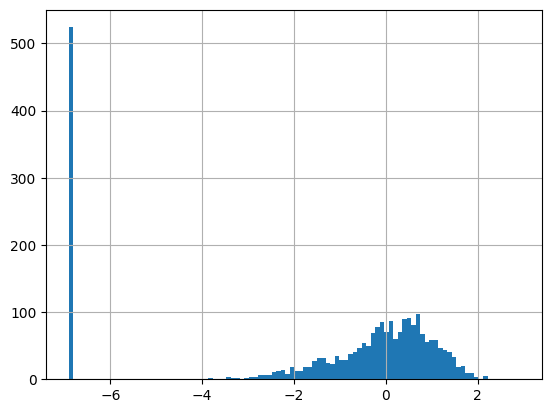

In [44]:
merge_counts = pd.merge(expected_aa_df.rename(columns={'current_aa':'parent_aa', 'transition_aa':'child_aa', 'substitution_probability':'expected_counts'}), observed_aa_df, on=['v_family', 'site', 'parent_aa', 'child_aa'])
merge_counts['ratio'] = merge_counts['mutation_acquired'] / merge_counts['expected_counts']
merge_counts['log_ratio'] = np.log(merge_counts['ratio'] + 1e-3)

merge_counts[merge_counts.expected_counts >= 1].log_ratio.hist(bins=100)



## load entrenches sites identified by DASM analysis

We separate sites into two types of evolutionarily constrained sites:
- Within v family entrenched sites
- Between v-family entrenched sites

Below, when we higlight entrenched sites in the scatter plots, we have one version for all sites and then one version for the within v family entrenched sites, as those are the more surprising ones that we wanted to focus on in validation.


In [ ]:

# Define highlight sites and their colors
#highlight_sites = {38: 'red', 55: 'orange', 40: 'green', 42: 'purple', 57: 'blue', 64: 'cyan', 66: 'magenta', 56:'brown', 106:'pink'}

# Load entrenchment data
entrenchment_directory = '_output/entrenchment_analysis/'

# Load "within" files and "vs" files separately
within_dfs = []
vs_dfs = []

for f in os.listdir(entrenchment_directory):
    file_path = os.path.join(entrenchment_directory, f)
    
    if 'within' in f:
        df = pd.read_csv(file_path)
        within_dfs.append(df)
    elif 'vs' in f:
        df = pd.read_csv(file_path)
        vs_dfs.append(df)

within_dfs = pd.concat(within_dfs, ignore_index=True)
vs_dfs = pd.concat(vs_dfs, ignore_index=True)


within_sites = within_dfs[['site', 'v_family']].drop_duplicates()
vs_sites = vs_dfs[['site', 'v_family']].drop_duplicates()
within_sites_aas = within_dfs[['site', 'v_family','amino_acid', 'target_amino_acid']].drop_duplicates()
vs_sites_aas = vs_dfs[['site', 'v_family','amino_acid', 'target_amino_acid']].drop_duplicates()


entrenched_sites = pd.concat([within_sites, vs_sites]).drop_duplicates().sort_values(['site', 'v_family'])
entrenched_sites_aas = pd.concat([within_sites_aas, vs_sites_aas]).drop_duplicates().sort_values(['site', 'v_family', 'amino_acid', 'target_amino_acid'])
print(len(entrenched_sites))
print(len(entrenched_sites_aas))


62
174


In [ ]:
# Create consistent color palette for entrenched sites
# Get all unique sites from your entrenched data
all_entrenched_sites = sorted(entrenched_sites_aas['site'].unique())

# Create the full palette
full_palette = sns.color_palette("tab20") + sns.color_palette("tab20b")[:5]

# Create a dictionary mapping each site to its color
site_color_map = {str(site): full_palette[i] for i, site in enumerate(all_entrenched_sites)}

print(f"Created color mapping for {len(site_color_map)} sites")

## Compare rate ratio to DASM

In [39]:
### compare to DASM

dataset_name = "v1rodriguez"
model_name = "dasm_4m-v1jaffeCC+v1tangCC-joint"


crepe_prefix = localify(f"DASM_TRAINED_MODELS_DIR/{model_name}")
test_output_prefix = localify(f"DASM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}")

try: # load data if already computed
    
    site_sub_probs_df = pd.read_csv(f"{test_output_prefix}-site_sub_probs_df.csv")
    pcp_df = pd.read_csv(f"{test_output_prefix}-pcp_df.csv")
    aa_site_subs_selection_df = pd.read_csv(f"{test_output_prefix}-aa_site_subs_selection_df.csv")

except FileNotFoundError:
    if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
        dasm_zoo.write_branch_lengths(localify(f"DASM_TRAINED_MODELS_DIR/{model_name}"), dataset_name, f"{test_output_prefix}.branch_lengths_csv")


    complete_plotter, plotter_dict = write_sites_oe(
        crepe_prefix=crepe_prefix,
        dataset_name=dataset_name,
        branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
        csv_output_path=f"{test_output_prefix}-sites-oe.csv",
        fig_out_path=f"{figures_dir}/sites-oe-V1,3,4.svg",
        min_log_prob=-4,
        #v_families=["IGHV1", "IGHV2", "IGHV3", "IGHV4", "IGHV5", "IGHV6", "IGHV7"],
        replace_title=True,
    )
    complete_plotter = complete_plotter["heavy"]

    pcp_df = complete_plotter.pcp_df.copy()
    site_sub_probs_df = complete_plotter.site_sub_probs_df.copy()
    aa_site_subs_selection_df = complete_plotter.aa_site_subs_selection_df.copy()

    pcp_df.to_csv(f"{test_output_prefix}-pcp_df.csv", index=False)
    site_sub_probs_df.to_csv(f"{test_output_prefix}-site_sub_probs_df.csv", index=False)
    aa_site_subs_selection_df.to_csv(f"{test_output_prefix}-aa_site_subs_selection_df.csv", index=False)


# add family annotations to aa and site substitution dfs
pcp_df['j_family'] = pcp_df['j_gene'].str.split('*').str[0]
pcp_df_for_merge = pcp_df.copy()
pcp_df_for_merge = pcp_df_for_merge[['v_gene', 'j_gene', 'v_family', 'j_family', 'sample_id', 'family', 'depth', 'distance']]
pcp_df_for_merge['pcp_index'] = pcp_df_for_merge.index

site_sub_probs_df = pd.merge(site_sub_probs_df, pcp_df_for_merge, on='pcp_index', how='inner')
aa_site_subs_selection_df = pd.merge(aa_site_subs_selection_df, pcp_df_for_merge, on='pcp_index', how='inner')
aa_site_subs_selection_df['log_selection_factor'] = np.log(aa_site_subs_selection_df.selection_factor)
## add germline information
germline_codons_df = pd.read_csv(localify(f"germline/germline_codons.csv"))
germline_codons_df['site'] = germline_codons_df['site'].astype(float)
aa_site_subs_selection_df_germline = pd.merge(aa_site_subs_selection_df, germline_codons_df.rename(columns={'codon':'germline_codon', 'amino_acid':'germline_amino_acid'}).drop(columns=['v_family']), on=['v_gene', 'site'], how='left')
aa_site_subs_selection_df_germline['is_germline_aa'] = aa_site_subs_selection_df_germline.parent_aa == aa_site_subs_selection_df_germline.germline_amino_acid
aa_site_subs_selection_df_germline['is_germline_codon'] = aa_site_subs_selection_df_germline.parent_codon == aa_site_subs_selection_df_germline.germline_codon

dasm_summarized = aa_site_subs_selection_df_germline[aa_site_subs_selection_df_germline.is_germline_aa == True].groupby(['v_family', 'site', 'parent_aa', 'selection_factor_target_aa']).selection_factor.median().reset_index()


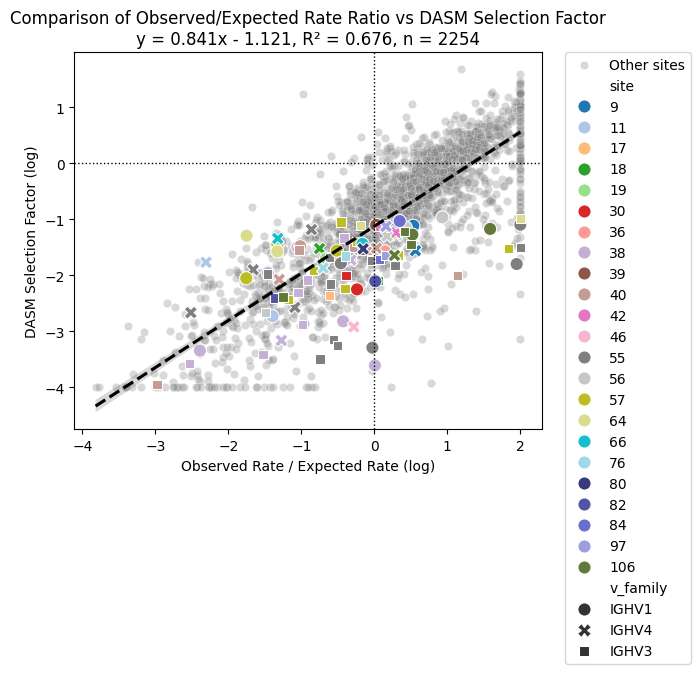

In [56]:

compare_dasm_rates = pd.merge(merge_counts, dasm_summarized.rename(columns={'selection_factor_target_aa':'child_aa'}), on=['v_family', 'site', 'parent_aa', 'child_aa'], suffixes=('_rates', '_dasm'))
compare_dasm_rates['log_selection_factor'] = np.log(compare_dasm_rates['selection_factor'])

# clip very low and very high values
compare_dasm_rates['log_selection_factor'] = compare_dasm_rates['log_selection_factor'].clip(lower=-4, upper=2)
compare_dasm_rates['log_ratio'] = compare_dasm_rates['log_ratio'].clip(lower=-4, upper=2)

compare_dasm_rates = compare_dasm_rates[compare_dasm_rates.mutation_acquired >= 1]

# Calculate regression statistics
x = compare_dasm_rates['log_ratio']
y = compare_dasm_rates['log_selection_factor']

# Remove any NaN values for regression calculation
mask = ~(np.isnan(x) | np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

# Calculate linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
r_squared = r_value ** 2
n = len(x_clean)


# Create the plot
fig, ax = plt.subplots(figsize=(7, 6))

# Plot regular points in blue
sns.scatterplot(data=compare_dasm_rates,
                x='log_ratio', y='log_selection_factor',
                color='grey', alpha=0.3, label='Other sites')

# filter entrenched data
#entrenched_compare_rates_dasm = pd.merge(entrenched_sites_aas, compare_dasm_rates, on=['site', 'v_family'], how='inner')
entrenched_compare_rates_dasm = pd.merge(entrenched_sites_aas.rename(columns={'amino_acid':'parent_aa', 'target_amino_acid':'child_aa'}), compare_dasm_rates, on=['site', 'v_family', 'parent_aa', 'child_aa'], how='inner')
# plot entrenched points in color
entrenched_compare_rates_dasm['site'] = entrenched_compare_rates_dasm['site'].astype(str)
sns.scatterplot(data=entrenched_compare_rates_dasm,
                x='log_ratio', y='log_selection_factor',
                s=90, hue='site', style='v_family', palette=site_color_map)

# Add the regression line
sns.regplot(data=compare_dasm_rates, x='log_ratio', y='log_selection_factor',
            scatter=False, line_kws={'linestyle': '--', 'color': 'black'})

ax.axvline(0, color='black', linestyle=':', linewidth=1)
ax.axhline(0, color='black', linestyle=':', linewidth=1)

# Add legend
plt.legend()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.xlabel('Observed Rate / Expected Rate (log)')
plt.ylabel('DASM Selection Factor (log)')

# Format the equation and R² for the title
if intercept >= 0:
    equation = f'y = {slope:.3f}x + {intercept:.3f}'
else:
    equation = f'y = {slope:.3f}x - {abs(intercept):.3f}'

title = f'Comparison of Observed/Expected Rate Ratio vs DASM Selection Factor\n{equation}, R² = {r_squared:.3f}, n = {n}'
plt.title(title)

plt.tight_layout()
plt.show()
